# Tech Challenge - Data Analytics [FASE 02]

Classificando Vinhos com Machine Learning

### Conhecendo o Dataset:

Descrição no Kaggle:

"Este conjunto de dados está relacionado às variantes tintas do vinho português "Vinho Verde". O conjunto de dados descreve a quantidade de vários compostos químicos presentes no vinho e seu efeito na qualidade do mesmo. Os dados podem ser vistos como tarefas de classificação ou regressão. As classes são ordenadas e não balanceadas (por exemplo, há muito mais vinhos normais do que excelentes ou ruins). Sua tarefa é prever a qualidade do vinho usando os dados fornecidos.

Um projeto simples, porém desafiador: prever a qualidade do vinho.
A complexidade reside no fato de o conjunto de dados possuir poucas amostras e ser altamente desbalanceado.
Você consegue superar esses obstáculos e construir um bom modelo preditivo para classificá-las?"

O conjunto de dados contém variáveis como:

● Acidez fixa (fixed acidity);

● Acidez volátil (volatile acidity);

● Ácido cítrico (citric acid);

● Açúcar residual (residual sugar);

● Cloretos (chlorides);

● Dióxido de enxofre livre (free sulfur dioxide);

● Dióxido de enxofre total (total sulfur dioxide);

● Densidade (density);

● pH;

● Sulfatos (sulphates);

● Teor alcoólico (alcohol);

● Qualidade do vinho (quality).

## Explorando a base de dados

In [106]:
# Importando as bibliotecas padrões para exploração e visualização dos dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
# Importando o dataset
df = pd.read_csv("WineQT.csv", sep = ",")

df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [108]:
# Dimensão da Base
print ("Total de linhas e colunas: ", df.shape)

Total de linhas e colunas:  (1143, 13)


In [109]:
# Formatação dos valores
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [110]:
# Valores únicos
df.nunique()

fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
dtype: int64

Apenas o ID possui valores únicos.

In [111]:
# Valores nulos
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Não há valores nulos.

In [112]:
# Linhas/registros duplicados

print("Registros duplicados")
duplicados = df.drop(columns=['Id']).duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Registros duplicados
Quantidade de registros duplicados: 125


In [113]:
# Exlcusão de duplicados

vinhos = df.drop(columns=['Id']).drop_duplicates()
print(f"Linhas antes: {len(df)}, Linhas depois: {len(vinhos)}")

Linhas antes: 1143, Linhas depois: 1018


In [114]:
# Estatistica básica das variáveis (arredondando duas casas decimais)
vinhos.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00
mean,8.29,0.53,0.27,2.52,0.09,15.65,46.33,1.00,3.31,0.66,10.45,5.64
std,1.74,0.18,0.20,1.31,0.05,10.18,33.12,0.00,0.16,0.17,1.10,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,21.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.25,2.20,0.08,13.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.10,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.72,11.20,6.00
max,15.90,1.58,1.00,15.50,0.61,68.00,289.00,1.00,4.01,2.00,14.90,8.00


Observando as mínimas e máximas das variáveis, foi identificado que os valores estão em escalas diferentes, como: "free sulfur dioxide" de 1.00 a 68.00, "total sulfur dioxide" de 6.00 a 289.00 e "chlorides" de varia de 0.01 a 0.61. 

Os modelos a serem treinados podem ser prejudicados por conta dessa diferença nas escalas de valores. 

Será necessário identificar se há outliers para definidir o melhor caminho: normalização ou padronização das variáveis. 

In [115]:
# Informações gerais
vinhos.info()

<class 'pandas.DataFrame'>
Index: 1018 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1018 non-null   float64
 1   volatile acidity      1018 non-null   float64
 2   citric acid           1018 non-null   float64
 3   residual sugar        1018 non-null   float64
 4   chlorides             1018 non-null   float64
 5   free sulfur dioxide   1018 non-null   float64
 6   total sulfur dioxide  1018 non-null   float64
 7   density               1018 non-null   float64
 8   pH                    1018 non-null   float64
 9   sulphates             1018 non-null   float64
 10  alcohol               1018 non-null   float64
 11  quality               1018 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 103.4 KB


In [116]:
# Identificando os valores da variável target (quality)
vinhos["quality"].unique()

array([5, 6, 7, 4, 8, 3])

In [117]:
# Identificando os valores da variável target (quality)
vinhos["quality"].value_counts()

quality
5    433
6    409
7    122
4     33
8     15
3      6
Name: count, dtype: int64

Apesar da variável ser de 0 a 10, apenas seis notas foram dadas para classificar a qualidade dos vinhos.

A maioria dos vinhos tem notas 5 e 6 de qualidade.

## Visualizando as Variáveis

### Gráficos das Variávais e Outliers 

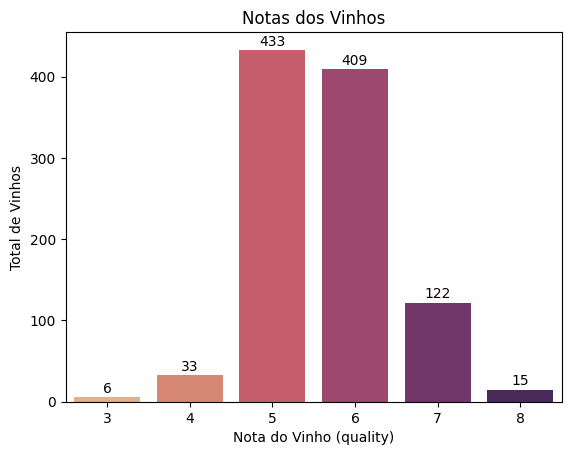

In [118]:
# Visualização da variável target (quality)

ax = sns.countplot(x="quality", data=vinhos, hue="quality", palette = "flare", legend=False)

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 1),
            textcoords="offset points",
        )

plt.xlabel("Nota do Vinho (quality)")
plt.ylabel("Total de Vinhos")
plt.title("Notas dos Vinhos")
plt.show()

Conforme identificado anteriormente, grande parte dos vinhos foram classificados com notas 5 e 6 (medianos)

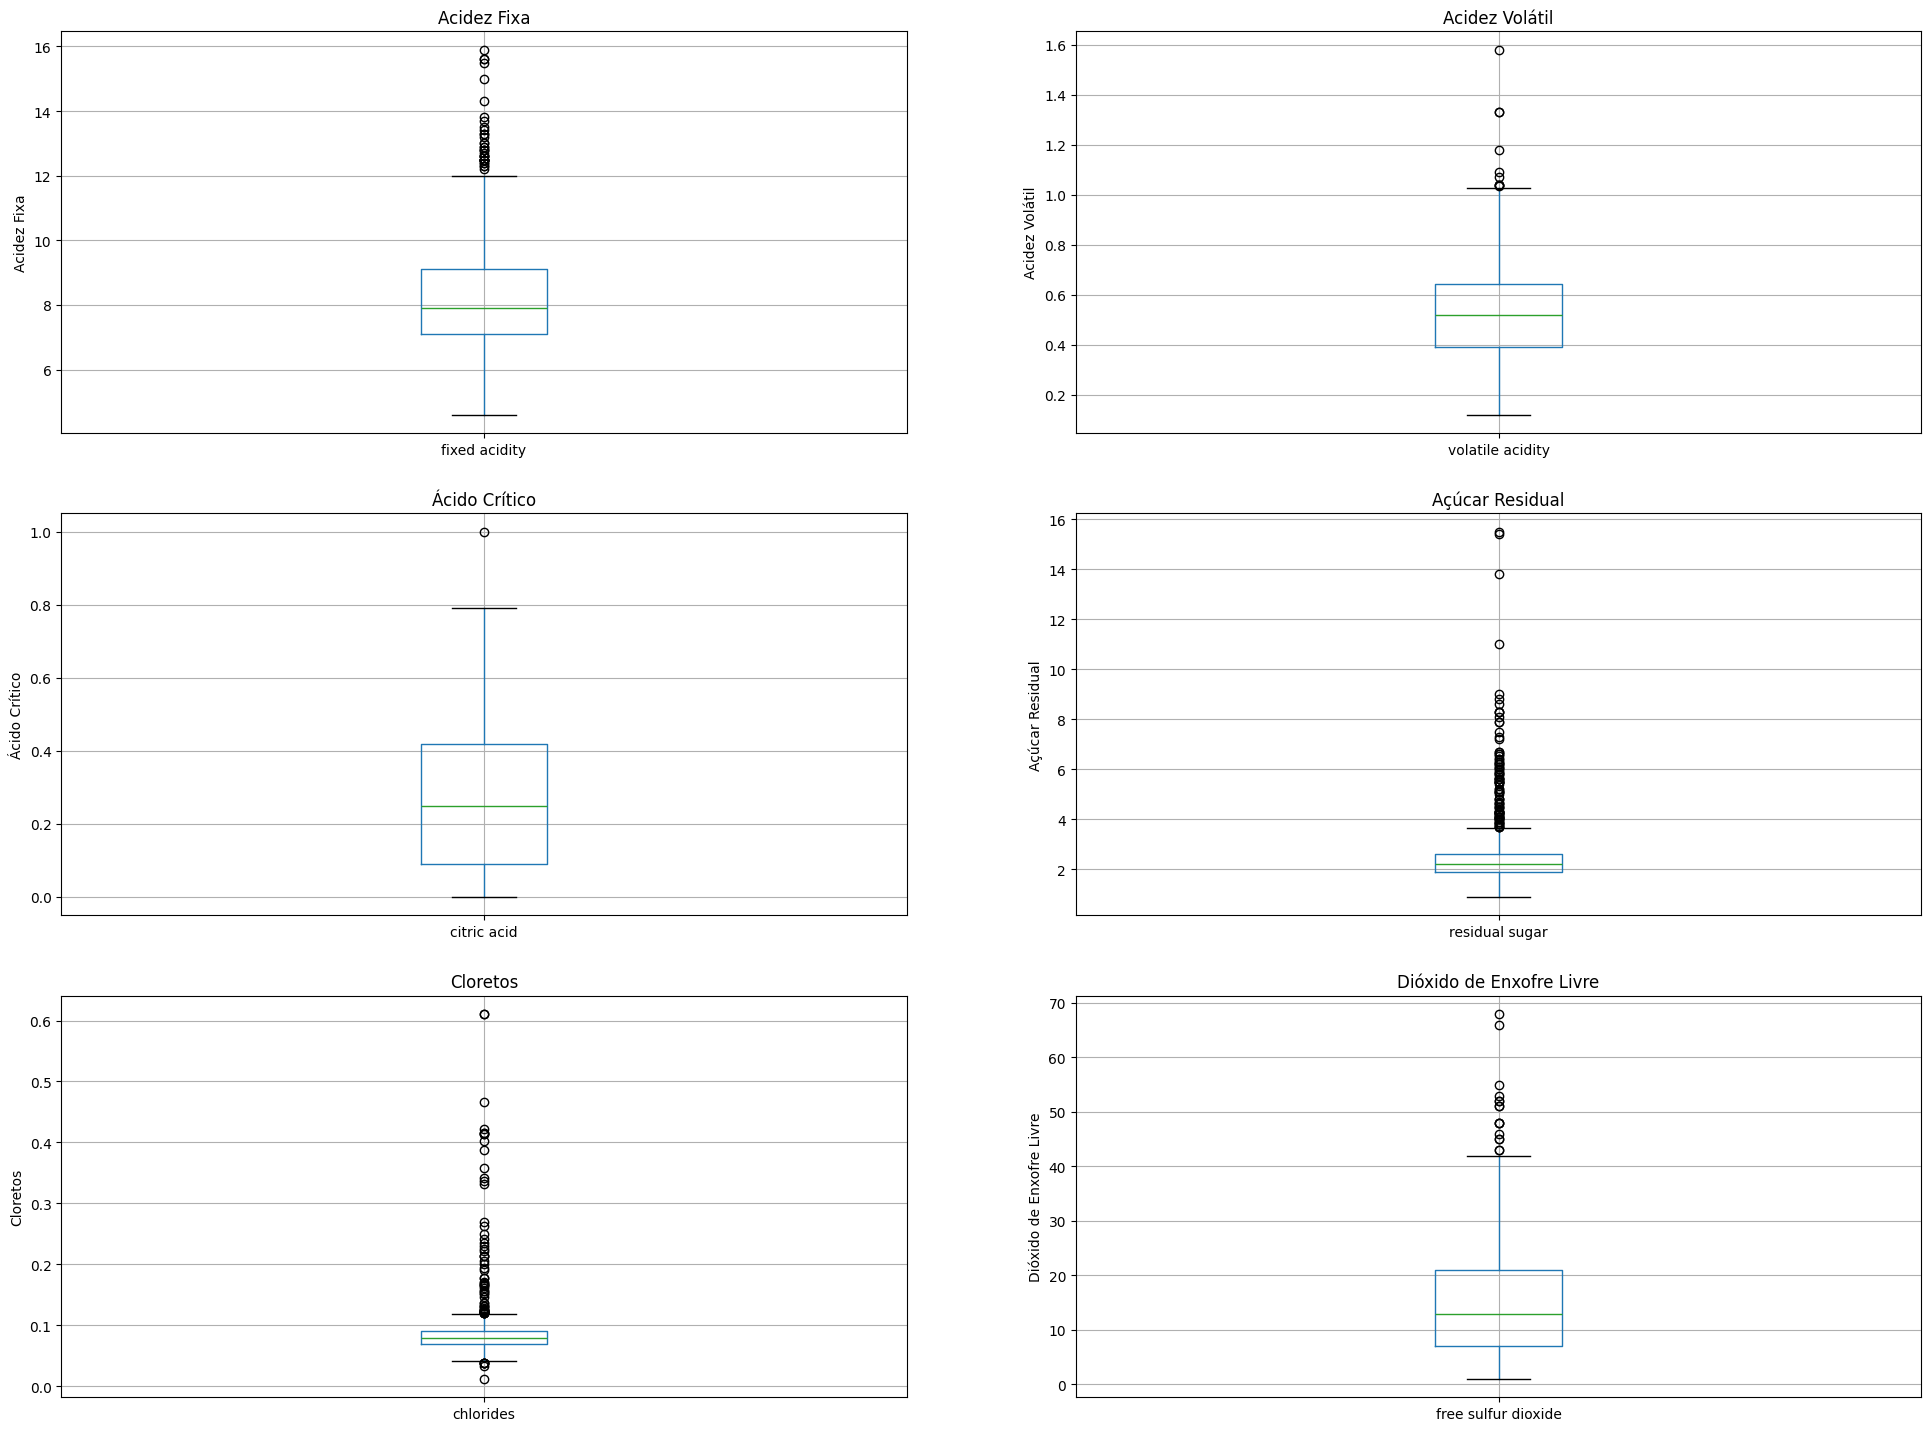

In [119]:
# Gráfico Boxplot para visualizar os outliers 

plt.figure(figsize=(24,24))

plt.subplot(4, 2, 1)
fig = vinhos.boxplot(column = "fixed acidity")
fig.set_title("Acidez Fixa")
fig.set_ylabel("Acidez Fixa")

plt.subplot(4, 2, 2)
fig = vinhos.boxplot(column = "volatile acidity")
fig.set_title("Acidez Volátil")
fig.set_ylabel("Acidez Volátil")

plt.subplot(4, 2, 3)
fig = vinhos.boxplot(column = "citric acid")
fig.set_title("Ácido Crítico")
fig.set_ylabel("Ácido Crítico")

plt.subplot(4, 2, 4)
fig = vinhos.boxplot(column = "residual sugar")
fig.set_title("Açúcar Residual")
fig.set_ylabel("Açúcar Residual")

plt.subplot(4, 2, 5)
fig = vinhos.boxplot(column = "chlorides")
fig.set_title("Cloretos")
fig.set_ylabel("Cloretos")

plt.subplot(4, 2, 6)
fig = vinhos.boxplot(column = "free sulfur dioxide")
fig.set_title("Dióxido de Enxofre Livre")
fig.set_ylabel("Dióxido de Enxofre Livre")

plt.show()

É possível observar outliers bem expressivos nas variáveis "residual sugar" e "chlorides", assim como outros outliers menos expressivos, porém existentes nas demais variáveis.

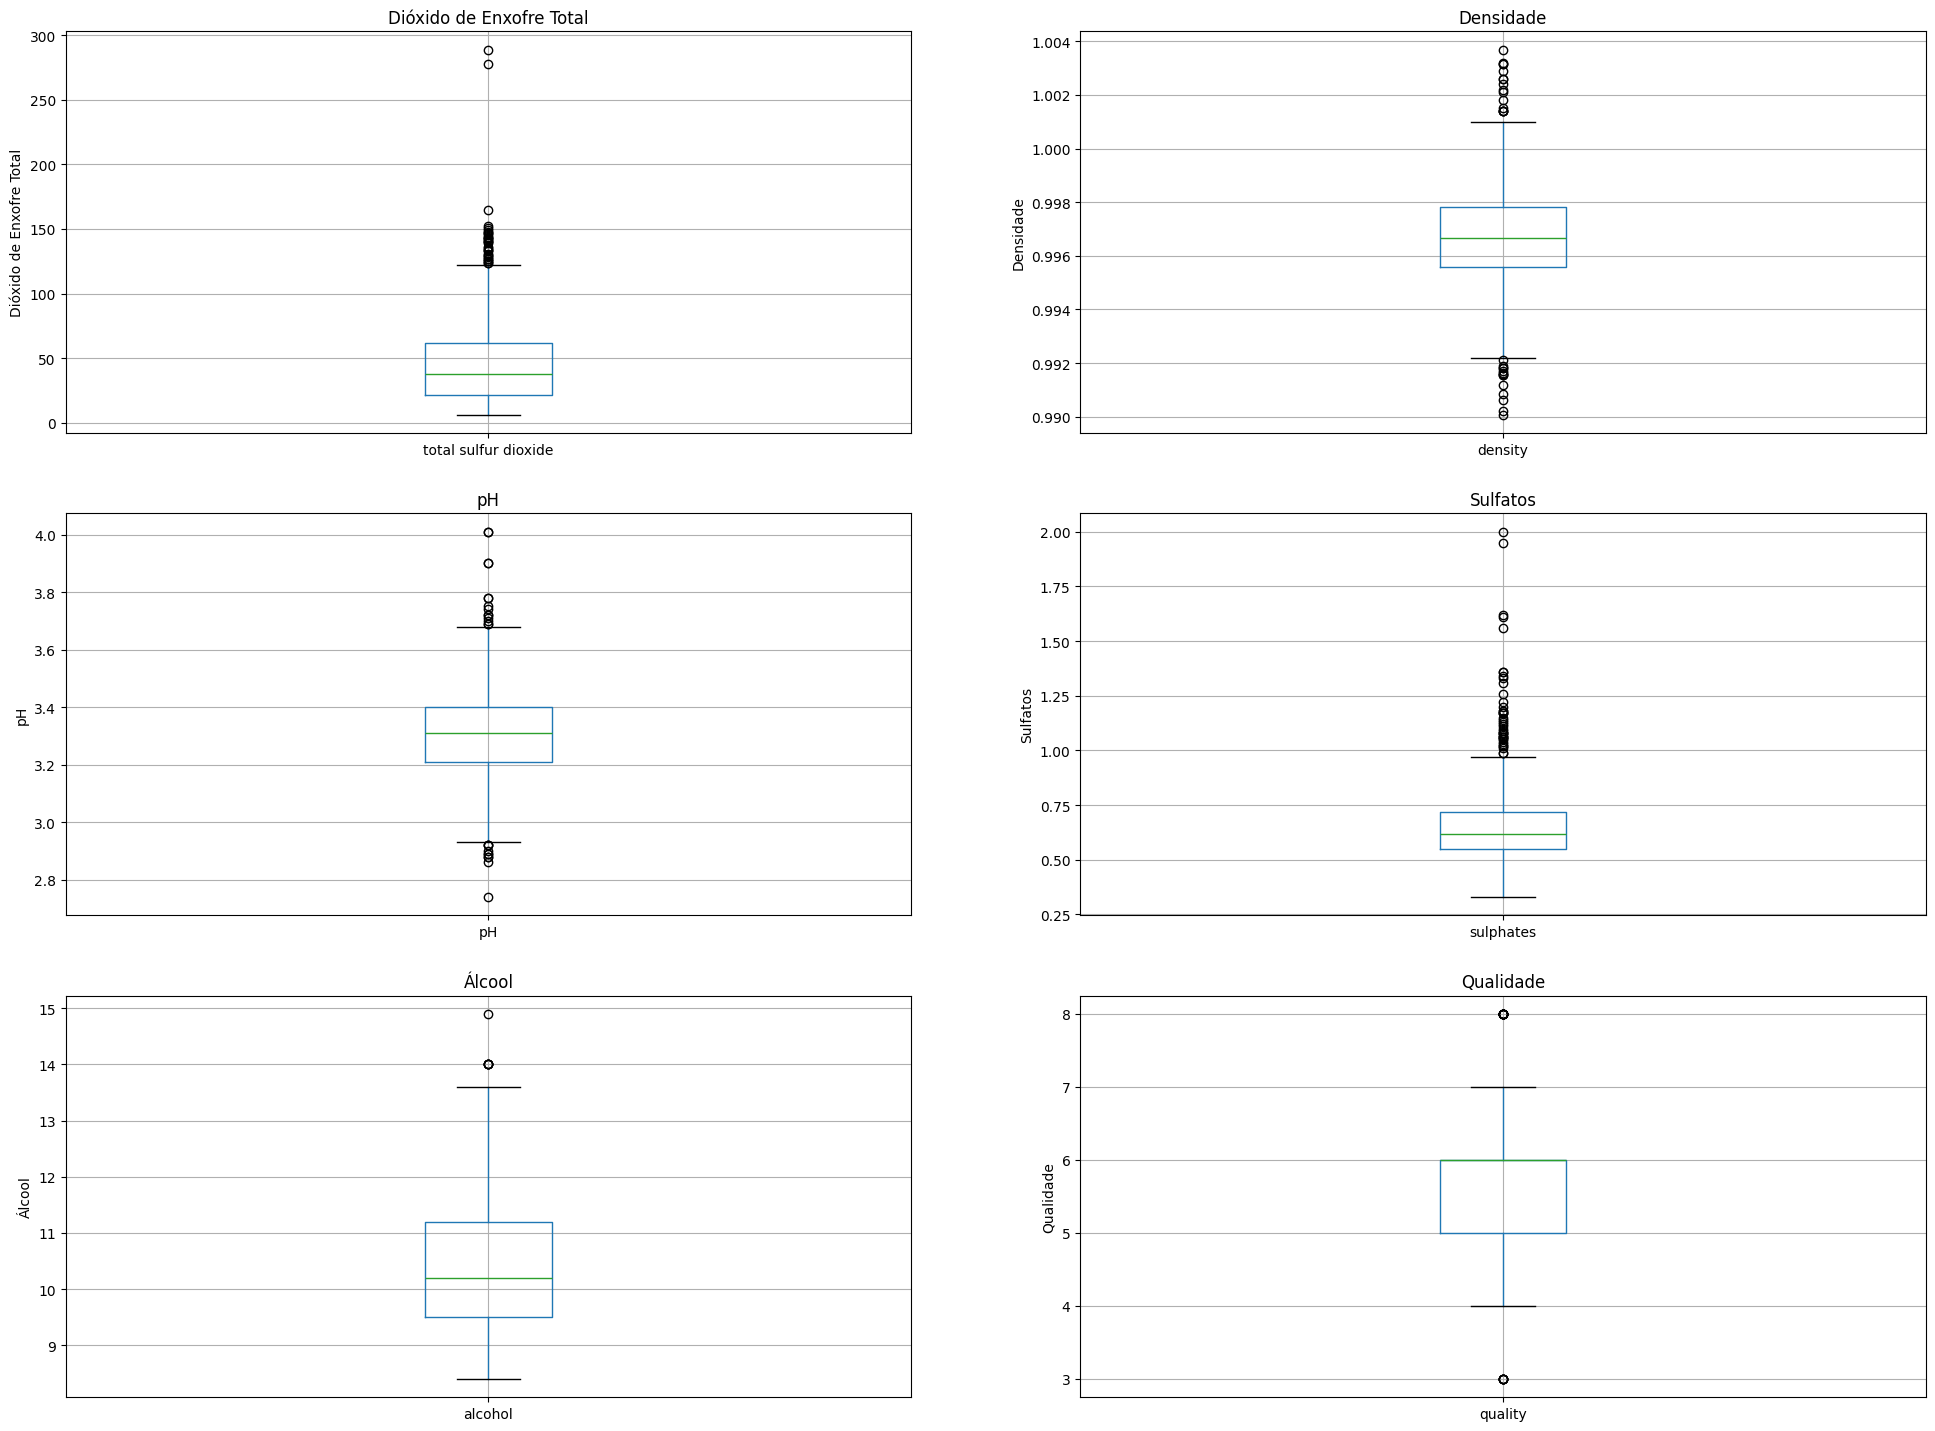

In [120]:
# Gráfico Boxplot para visualizar os outliers 

plt.figure(figsize=(24,24))

plt.subplot(4, 2, 1)
fig = vinhos.boxplot(column = "total sulfur dioxide")
fig.set_title("Dióxido de Enxofre Total")
fig.set_ylabel("Dióxido de Enxofre Total")

plt.subplot(4, 2, 2)
fig = vinhos.boxplot(column = "density")
fig.set_title("Densidade")
fig.set_ylabel("Densidade")

plt.subplot(4, 2, 3)
fig = vinhos.boxplot(column = "pH")
fig.set_title("pH")
fig.set_ylabel("pH")

plt.subplot(4, 2, 4)
fig = vinhos.boxplot(column = "sulphates")
fig.set_title("Sulfatos")
fig.set_ylabel("Sulfatos")

plt.subplot(4, 2, 5)
fig = vinhos.boxplot(column = "alcohol")
fig.set_title("Álcool")
fig.set_ylabel("Álcool")

plt.subplot(4, 2, 6)
fig = vinhos.boxplot(column = "quality")
fig.set_title("Qualidade")
fig.set_ylabel("Qualidade")

plt.show()

A outra metade da tabela também apresenta outliers expressivos ("total sulfur dioxide" e "sulphates"), além de outros.

### Correlação das Variáveis

Text(0.5, 1.0, 'Correlação de todas as variáveis')

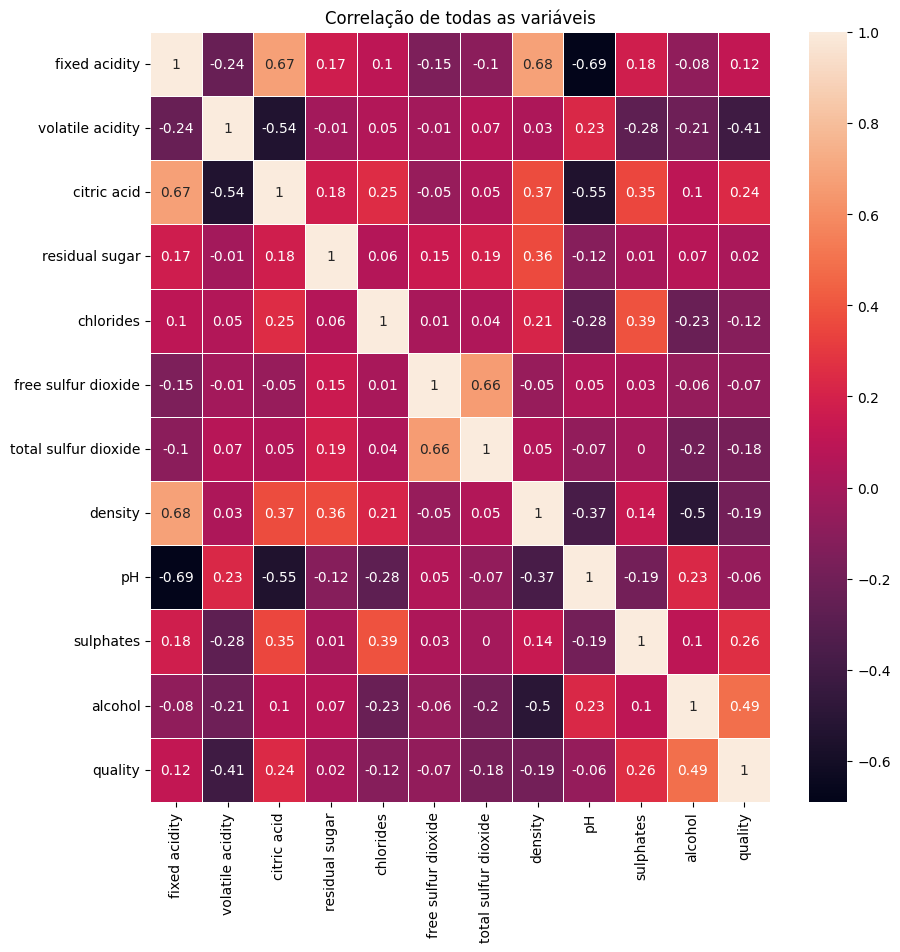

In [121]:
# Visualizando a correlação das variáveis
correlation_matrix = vinhos.corr().round(2)

fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)
plt.title("Correlação de todas as variáveis")

Observando o comportamento das variáveis com a variável target (quality):


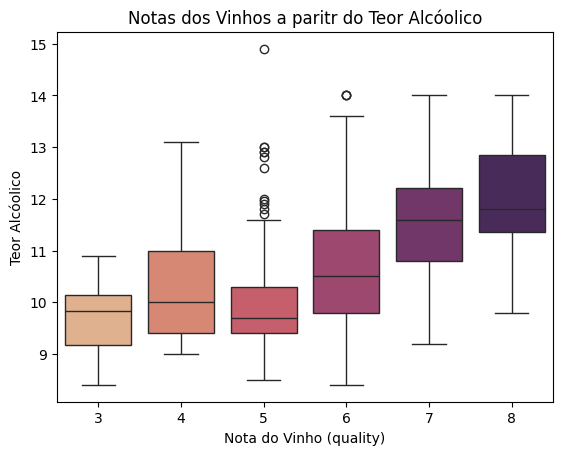

In [122]:
# Correlação do Álcool com a Qualidade

sns.boxplot(x="quality", y="alcohol", data=vinhos, hue="quality", palette="flare", legend=False)

plt.xlabel("Nota do Vinho (quality)")
plt.ylabel("Teor Alcóolico")
plt.title("Notas dos Vinhos a paritr do Teor Alcóolico")
plt.show()

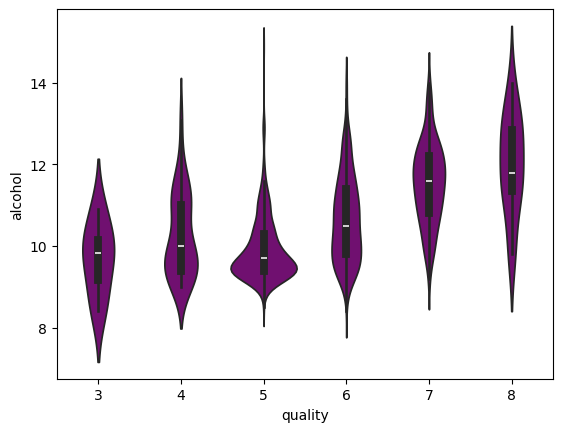

In [123]:
# Correlação do Álcool com a Qualidade

sns.violinplot(x='quality', y='alcohol', data=vinhos, color = "purple")
plt.show()

Sobre a correlação do Álcool com a Qualidade: grande parte dos vinhos com as notas 7 e 8 possui o teor alcoólico mais alto em relação às demais. Mas, ainda assim, existem vinhos com notas altas e teor alcoólico mais baixo (abaixo de 10, onde se concentra uma boa parte dos vinhos de notas mais baixas). 

Portanto, a hipótese é de que o teor alcoólico pode influenciar na qualidade do vinho, mas não é uma variável determinante. 

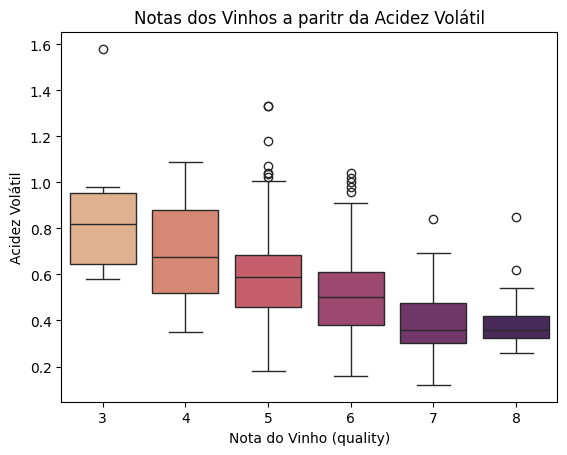

In [124]:
# Correlação da Acidez Volátil com a Qualidade

sns.boxplot(x="quality", y="volatile acidity", data=vinhos, hue="quality", palette="flare", legend=False)

plt.xlabel("Nota do Vinho (quality)")
plt.ylabel("Acidez Volátil")
plt.title("Notas dos Vinhos a paritr da Acidez Volátil")
plt.show()

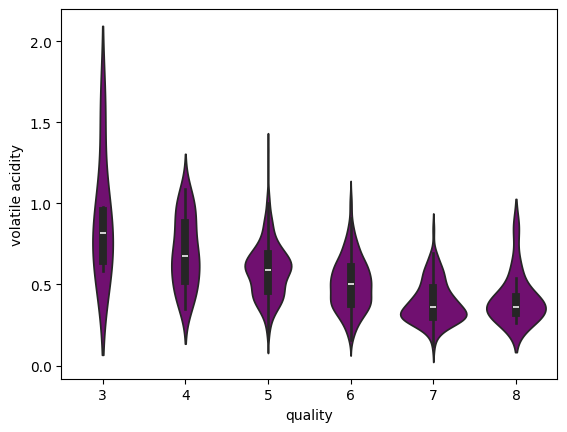

In [125]:
# Correlação da Acidez Volátil com a Qualidade

sns.violinplot(x='quality', y='volatile acidity', data=vinhos, color = "purple")
plt.show()

Diferente da correlação anterior, a Acidez Volátil é menor nos vinhos com as maiores notas. A maior parte dos vinhos com notas 7 e 8 não chegam a 0.6 de acidez volátil, enquanto grande parte dos vinhos com notas baixas possuem acidez volátil acima de 0.5.

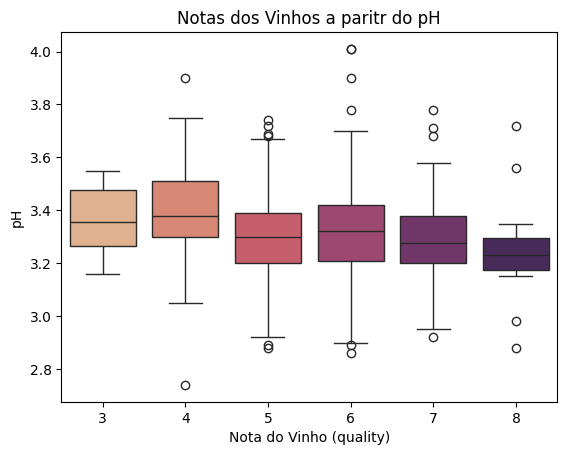

In [126]:
# Correlação do pH com a Qualidade

sns.boxplot(x="quality", y="pH", data=vinhos, hue="quality", palette="flare", legend=False)

plt.xlabel("Nota do Vinho (quality)")
plt.ylabel("pH")
plt.title("Notas dos Vinhos a paritr do pH")
plt.show()

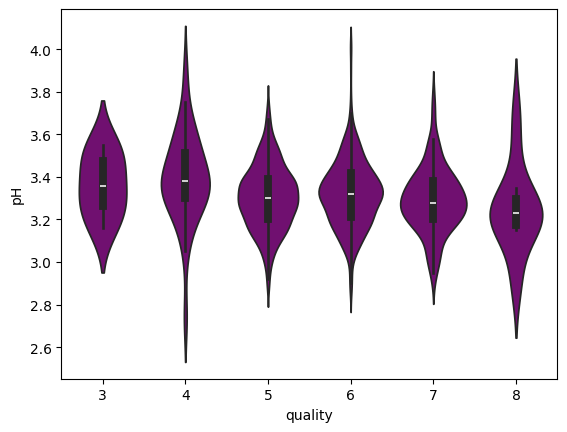

In [127]:
# Correlação do pH com a Qualidade

sns.violinplot(x='quality', y='pH', data=vinhos, color = "purple")
plt.show()

A correlação entre o pH e a Qualidade não expressa tanta diferença entre as notas. Mas, ainda assim, os vinhos com notas 7 e 8 possuem o pH menor que as demais, com exceção de grande parte dos vinhos com nota 5. 

Sendo assim, como se relacionam estas principais variáveis (Álcool, Acidez Volátil e ph) com a variável target (Qualidade)?

## Balanceamento das Classes

Para a variável target, será criada uma classificação binária considerando: 

Vinhos com notas maiores ou igual a 7 = bom (1)

Vinhos com notas menores que 7 = ruim (0)

In [128]:
# Verificando o balanceamento da classe binária
y = (vinhos["quality"] >= 7).astype(int)

print(y.value_counts(normalize=True) * 100)

quality
0    86.54224
1    13.45776
Name: proportion, dtype: float64


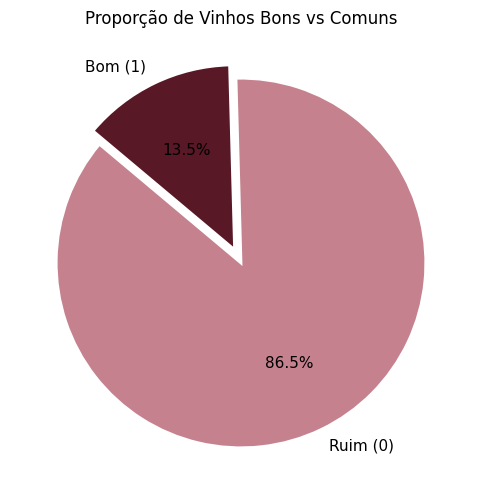

In [129]:
# Visualizando o balanceamento em gráfico de pizza
contagem = y.value_counts()

cores_vinho = ["#C5828E", "#581825"]

plt.figure(figsize=(6, 6))
plt.pie(
    contagem,
    labels=["Ruim (0)", "Bom (1)"],
    autopct="%1.1f%%",  
    startangle=140,
    colors=cores_vinho,
    explode=(0, 0.08),  
    textprops={"fontsize": 11, "color": "black"},
    wedgeprops={"edgecolor": "white", "linewidth": 2},  
)

plt.title("Proporção de Vinhos Bons vs Comuns")
plt.show()

Considerando que a base não está balanceada, visto que grande parte dos vinhos estão classificados como "ruim" (0), será necessário distribuir proporcionalmente estes percentuais nas bases de treino e teste. 

Será utilizado o comando stratify=y para garantir que as bases contenham, aleatoriamente, 86% de vinhos ruins e 14% de vinhos bons. 

### Sepração da Base em Treino e Teste

Após explorar e visualizar os dados e antes de padronizar as variáveis, é necessário separar a base para treino e teste. 

In [130]:
# Separando a variável target das demais

from sklearn.model_selection import train_test_split

x = vinhos[["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates", "alcohol"]]
y = (vinhos["quality"] >= 7).astype(int)

In [131]:
# Separando 80% para Treino e 20% para Teste

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=101, stratify=y)

### Padronização das Variáveis

Considerando os outliers expressivos, é necessário aplicar a padronização nas variáveis, com exceção da variável target ("quality") e de identificação ("id").

O método de padronização utilizado é o RobustScaler, para utilizar a mediana e o intervalo interquartil. Dessa forma, os outliers não prejudicam a nova escala. 

In [132]:
from sklearn.preprocessing import RobustScaler

# Instanciando o RobustScaler
scaler = RobustScaler()

# Padronizando as bases x
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

PARA TREINAR OS MODELOS:

Se o modelo NÃO PRECISA das variáveis padronizadas (árvore de decisão), utilizar: x_train, x_test, y_train, y_test

Se o modelo PRECISA das variáveis padronizadas, utilizar: x_train_scaled, x_test_scaled, y_train, y_test

## Desenvolvendo Modelos

### Support Vector Classifier (SVC)

In [133]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Instanciando e treinando o modelo
modelo_svc = SVC(kernel='rbf', C=10.0, gamma='scale', class_weight='balanced')
modelo_svc.fit(x_train_scaled, y_train)

y_pred_svc = modelo_svc.predict(x_test_scaled)

# Avaliando as métricas
acuracia = accuracy_score(y_test, y_pred_svc)

print(f"Acurácia Support Vector Classifier: {acuracia:.4f}")
print(f"Acurácia: {acuracia * 100:.2f}%\n")
print("Nova Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_svc))
print("\nNovo Relatório de Classificação:")
print(classification_report(y_test, y_pred_svc))

Acurácia Support Vector Classifier: 0.8186
Acurácia: 81.86%

Nova Matriz de Confusão:
[[148  29]
 [  8  19]]

Novo Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       177
           1       0.40      0.70      0.51        27

    accuracy                           0.82       204
   macro avg       0.67      0.77      0.70       204
weighted avg       0.88      0.82      0.84       204



### Logistic Regression

In [134]:
from sklearn.linear_model import LogisticRegression

# Instanciando e treinando o modelo
model_logreg = LogisticRegression(random_state=101, class_weight='balanced')
model_logreg.fit(x_train_scaled, y_train)

y_pred_regre = model_logreg.predict(x_test_scaled)

# Avaliando as métricas
acuracia = accuracy_score(y_test, y_pred_regre)

print(f"Acurácia Logistic Regression: {acuracia:.4f}")
print(f"Acurácia: {acuracia * 100:.2f}%\n")
print("Nova Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_regre))
print("\nNovo Relatório de Classificação:")
print(classification_report(y_test, y_pred_regre))

Acurácia Logistic Regression: 0.7892
Acurácia: 78.92%

Nova Matriz de Confusão:
[[141  36]
 [  7  20]]

Novo Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       177
           1       0.36      0.74      0.48        27

    accuracy                           0.79       204
   macro avg       0.65      0.77      0.67       204
weighted avg       0.87      0.79      0.82       204



### Gaussian Naive Bayes

In [135]:
from sklearn.naive_bayes import GaussianNB

# Instanciando e treinando o modelo
model_gnb = GaussianNB()
model_gnb.fit(x_train_scaled, y_train)

y_pred_gnb = model_gnb.predict(x_test_scaled)

# Avaliando as métricas
print(f"Acurácia Gaussian Naive Bayes: {accuracy_score(y_test, y_pred_gnb):.4f}\n")
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_gnb))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_gnb))

Acurácia Gaussian Naive Bayes: 0.8578

Matriz de Confusão:
[[156  21]
 [  8  19]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91       177
           1       0.47      0.70      0.57        27

    accuracy                           0.86       204
   macro avg       0.71      0.79      0.74       204
weighted avg       0.89      0.86      0.87       204



### Decision Tree

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Instanciando e treinando o modelo com o total de 05 camadas
modelo_arvore = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth = 5)
modelo_arvore.fit(x_train, y_train)

y_pred_tree = modelo_arvore.predict(x_test)

# Avaliando as métricas
print(f"Acurácia Decision Tree Classifier: {accuracy_score(y_test, y_pred_tree):.4f}\n")
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_tree))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_tree))

Acurácia Decision Tree Classifier: 0.8824

Matriz de Confusão:
[[172   5]
 [ 19   8]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       177
           1       0.62      0.30      0.40        27

    accuracy                           0.88       204
   macro avg       0.76      0.63      0.67       204
weighted avg       0.86      0.88      0.86       204



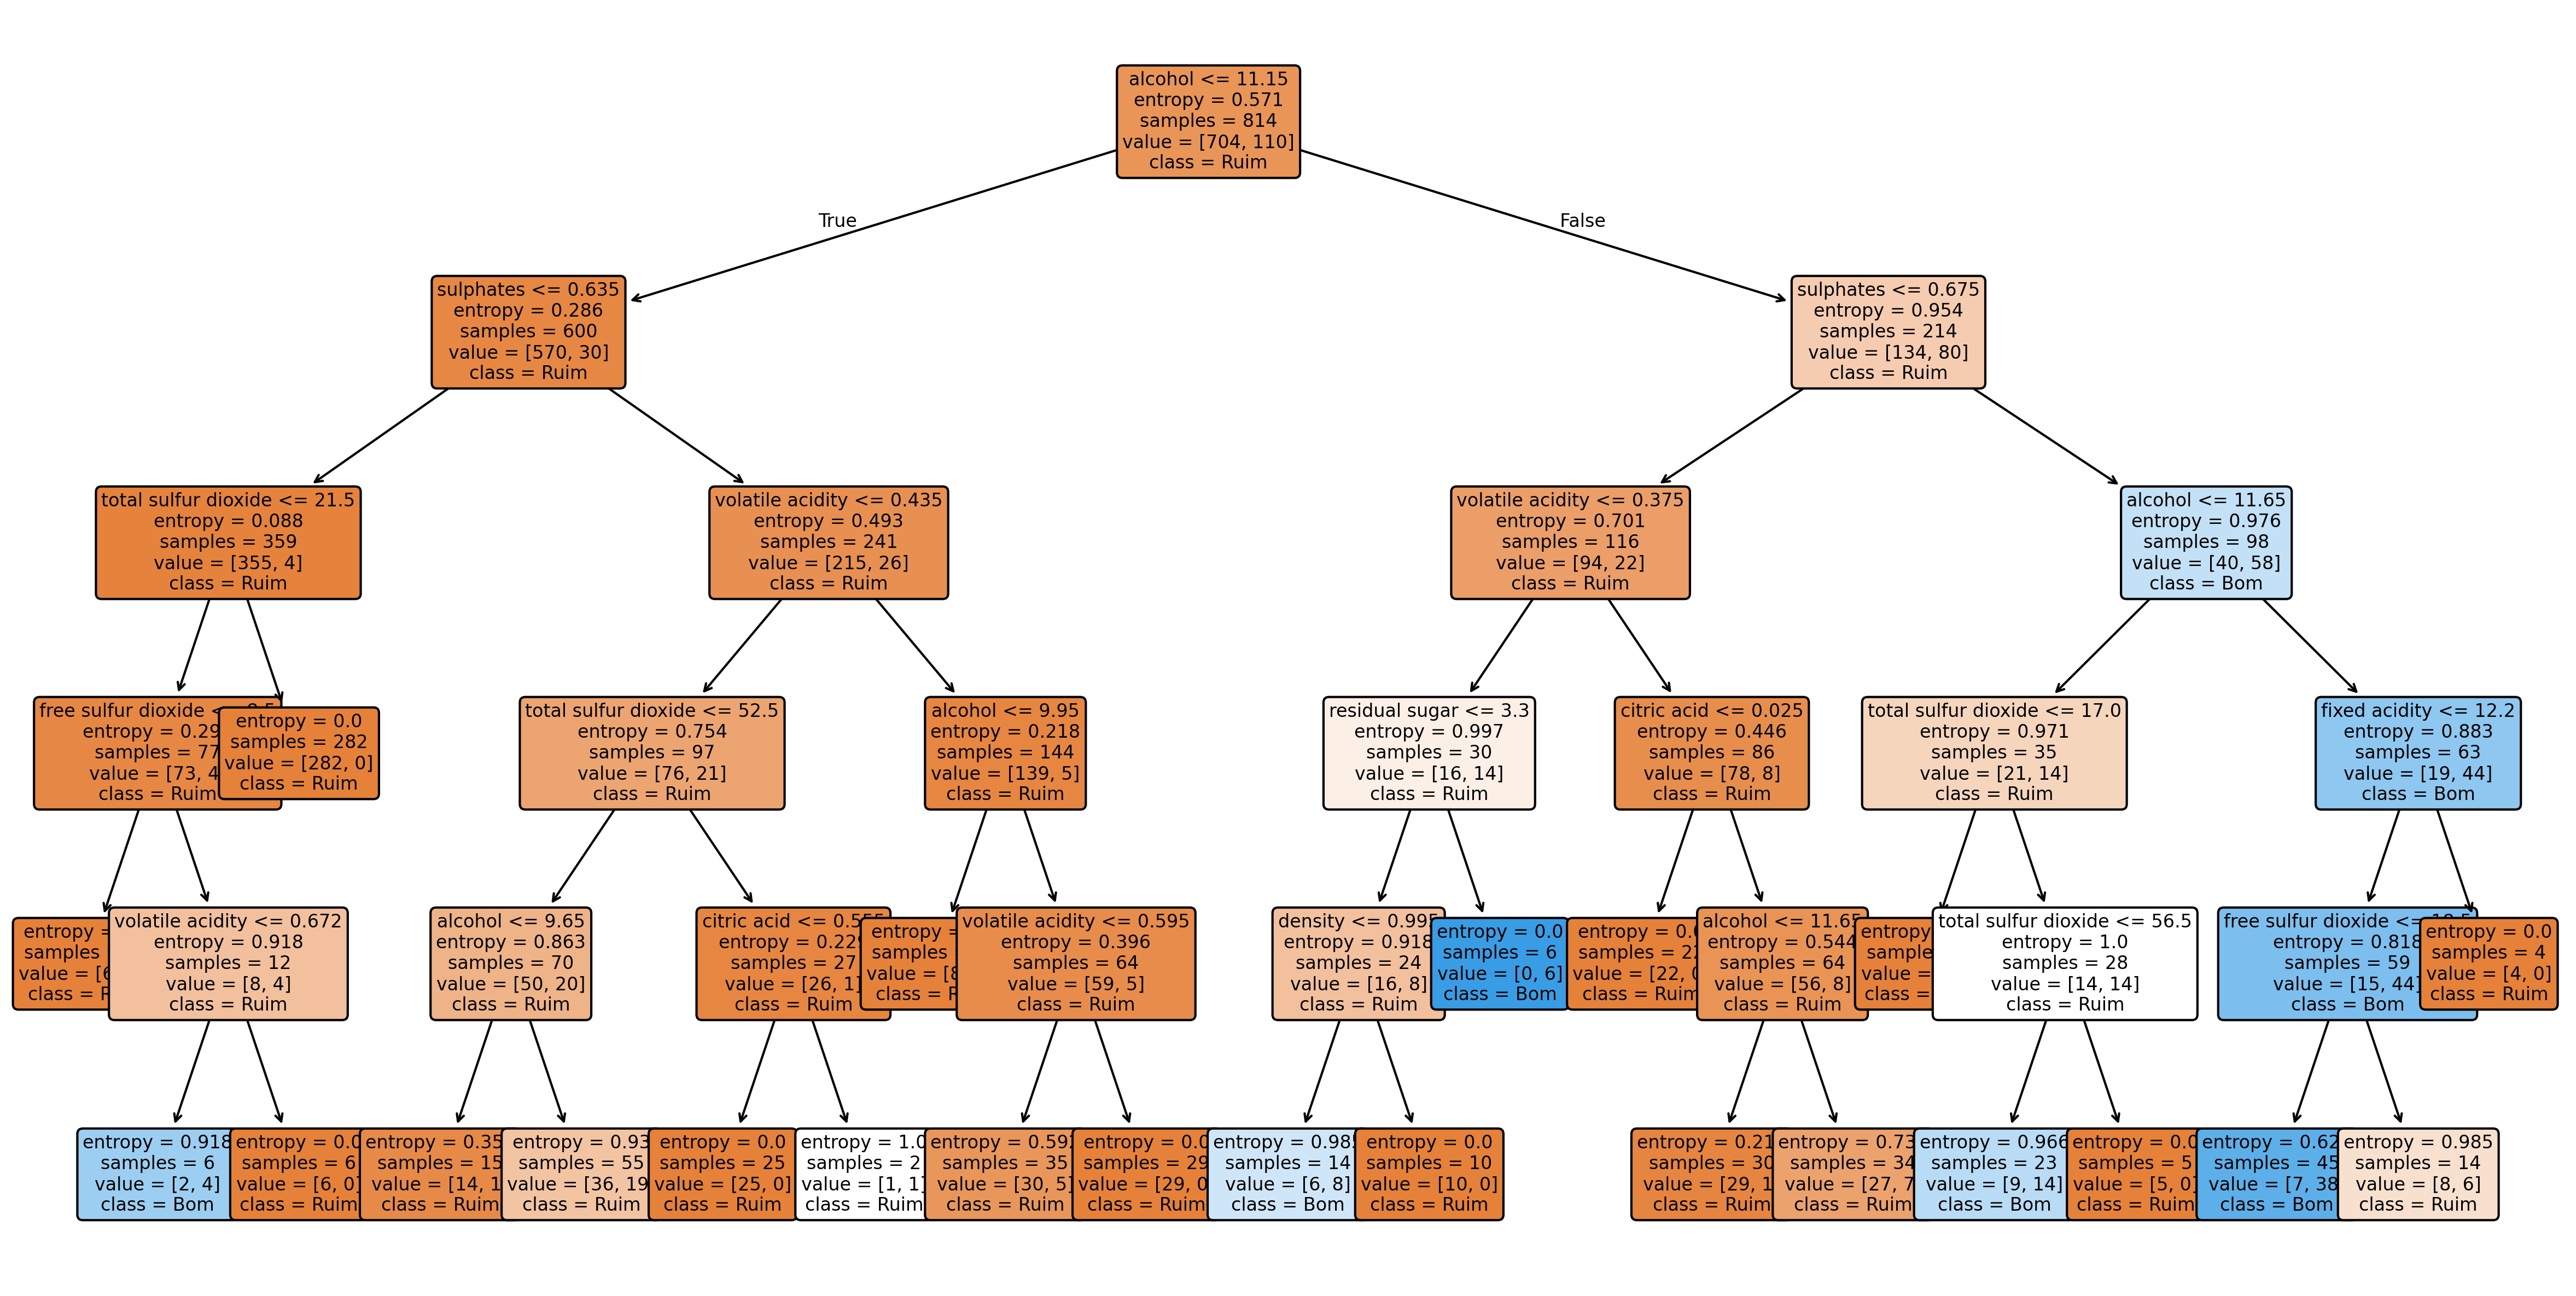

In [137]:
from sklearn import tree

class_names = ['Ruim', 'Bom']
label_names = list(x.columns)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 10), dpi=300)

plot_tree(
    modelo_arvore,
    feature_names=label_names,
    class_names=class_names,
    filled=True,
    rounded=True,  # Borda arredondada nas caixas (deixa visualmente mais bonito)
    fontsize=8,  # Ajuste do tamanho da fonte se a árvore for muito grande
)

plt.show()

### Random Forest

In [138]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz

# Instanciando e treinando o modelo com o total de 100 árvores de decisão
modelo_rf = RandomForestClassifier(
    n_estimators=100, random_state=101, class_weight="balanced"
)
modelo_rf.fit(x_train, y_train)

y_pred_rf = modelo_rf.predict(x_test)

# Avaliando as métricas
print(f"Acurácia Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf))



Acurácia Random Forest: 0.8775

Matriz de Confusão:
[[167  10]
 [ 15  12]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       177
           1       0.55      0.44      0.49        27

    accuracy                           0.88       204
   macro avg       0.73      0.69      0.71       204
weighted avg       0.87      0.88      0.87       204



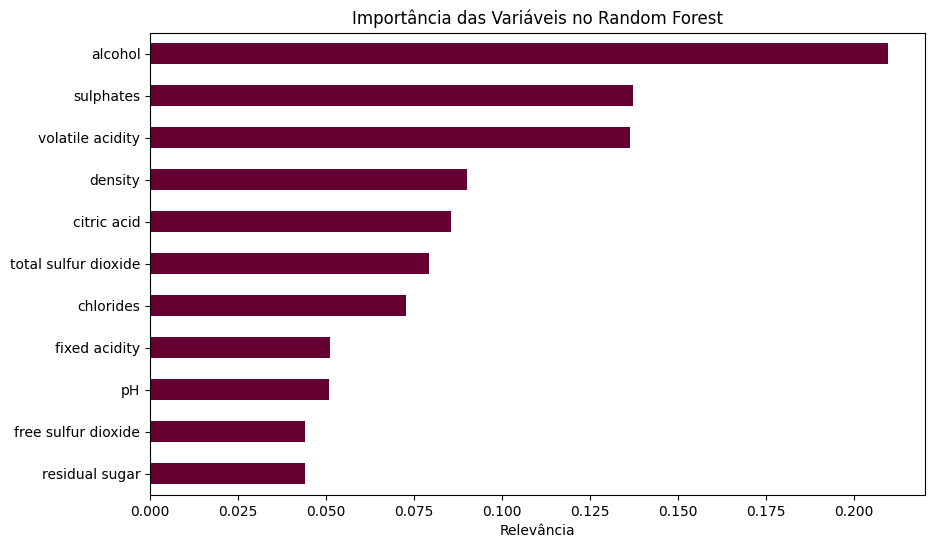

In [139]:
# Criando um DataFrame com a importância das variáveis e visualizando em gráfico
importancias = pd.Series(
    modelo_rf.feature_importances_, index=x.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind="barh", color="#660033")
plt.title("Importância das Variáveis no Random Forest")
plt.xlabel("Relevância")
plt.show()

### Gradient Boosting

In [140]:
from sklearn.ensemble import GradientBoostingClassifier

# Instanciando e treinando o modelo
modelo_gb = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1, max_depth=3, random_state=42)
modelo_gb.fit(x_train, y_train)
y_pred_gb = modelo_gb.predict(x_test)

# Avaliando as métricas
acuracia = accuracy_score(y_test, y_pred_gb)
print(f"Acurácia: {acuracia * 100:.2f}%\n")
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_gb))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_gb))

Acurácia: 87.75%

Matriz de Confusão:
[[170   7]
 [ 18   9]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       177
           1       0.56      0.33      0.42        27

    accuracy                           0.88       204
   macro avg       0.73      0.65      0.68       204
weighted avg       0.86      0.88      0.86       204



In [141]:
# Quais atributos foram mais importantes para a classificação

importancias = pd.DataFrame({"Variável": x.columns,"Importância": modelo_gb.feature_importances_})
importancias = importancias.sort_values(by="Importância",ascending=False)
importancias

,Variável,Importância
10,alcohol,0.315945
9,sulphates,0.153163
1,volatile acidity,0.148503
6,total sulfur dioxide,0.080210
7,density,0.053783
3,residual sugar,0.048612
4,chlorides,0.046278
0,fixed acidity,0.041067
2,citric acid,0.040851
5,free sulfur dioxide,0.040060


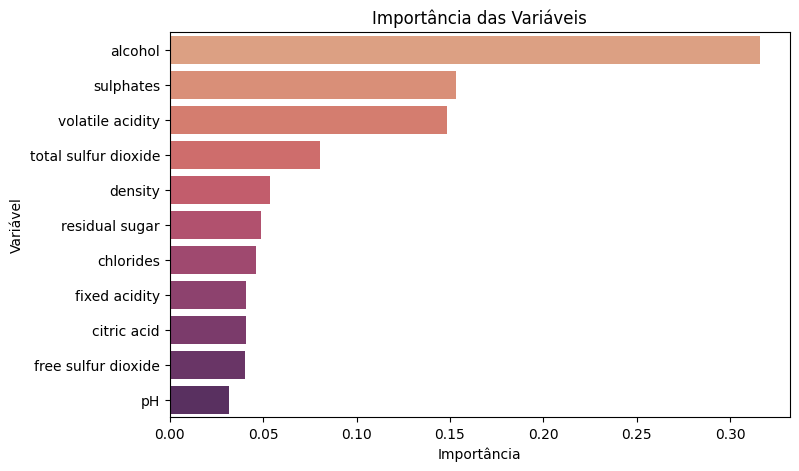

In [142]:
# Mostrando as relevancias em grafico 

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(data=importancias,x="Importância",y="Variável",hue="Variável",palette="flare",legend=False)

plt.title("Importância das Variáveis")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.show()

Conclusão – Gradient Boosting

O modelo Gradient Boosting apresentou acurácia de 88,65%, indicando um bom desempenho geral na classificação dos vinhos. Entretanto, apresentou maior dificuldade na identificação da classe "Bom", que obteve Recall de 43,75% e F1-Score de 51,85%, enquanto a classe "Ruim" apresentou desempenho superior.

A matriz de confusão mostrou 203 acertos em 229 amostras, sendo 189 classificações corretas de vinhos "Ruins" e 14 de vinhos "Bons". Esse resultado evidencia a influência do desbalanceamento entre as classes na capacidade do modelo de identificar os vinhos classificados como "Bons".

Na verificação de generalização, o modelo apresentou 97,05% de acurácia no conjunto de treinamento e 88,65% no conjunto de teste, indicando uma diferença de 8,40 pontos percentuais entre os conjuntos. Esse resultado sugere a existência de algum grau de sobreajuste (overfitting), embora o modelo ainda mantenha um desempenho satisfatório no conjunto de teste.

Por fim, entre as variáveis analisadas, alcohol, sulphates e volatile acidity apresentaram as maiores importâncias para as decisões do modelo.

### XGBoost

In [143]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Instanciando e treinando o modelo
modelo_xgb = XGBClassifier(random_state=42)


modelo_xgb.fit(x_train, y_train)

y_pred_xgb = modelo_xgb.predict(x_test)

# Avaliando as métricas
acuracia = accuracy_score(y_test, y_pred_xgb)
print(f"Acurácia: {acuracia * 100:.2f}%\n")
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_xgb))

Acurácia: 87.25%

Matriz de Confusão:
[[170   7]
 [ 19   8]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       177
           1       0.53      0.30      0.38        27

    accuracy                           0.87       204
   macro avg       0.72      0.63      0.65       204
weighted avg       0.85      0.87      0.86       204



### K Neighbors

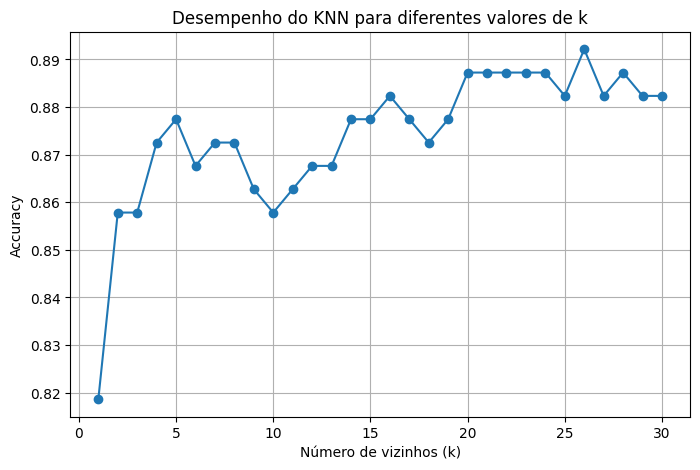

Melhor k: 26
Accuracy: 0.89


In [144]:
from sklearn.neighbors import KNeighborsClassifier

# Escolha do melhor k (número de vizinhos próximos)
resultados = []

for k in range(1,31):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(x_train_scaled, y_train)

    y_pred_k = knn.predict(x_test_scaled)

    resultados.append(accuracy_score(y_test, y_pred_k))


plt.figure(figsize=(8,5))

plt.plot(range(1,31), resultados, marker="o")

plt.xlabel("Número de vizinhos (k)")
plt.ylabel("Accuracy")
plt.title("Desempenho do KNN para diferentes valores de k")

plt.grid(True)

plt.show()

# Melhor k
melhor_k = resultados.index(max(resultados)) + 1

print(f"Melhor k: {melhor_k}")
print(f"Accuracy: {max(resultados):.2f}")

In [145]:
# Instanciando e treinando o modelo com 5 vizinhos próximos
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

y_pred_KNN = knn.predict(x_test_scaled)

# Avaliando as métricas
acuracia = accuracy_score(y_test, y_pred_KNN)
print(f"Acurácia: {acuracia * 100:.2f}%\n")
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_KNN))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_KNN))

Acurácia: 87.75%

Matriz de Confusão:
[[171   6]
 [ 19   8]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       177
           1       0.57      0.30      0.39        27

    accuracy                           0.88       204
   macro avg       0.74      0.63      0.66       204
weighted avg       0.86      0.88      0.86       204



In [146]:
# Instanciando e treinando o modelo com 13 vizinhos próximos
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(x_train_scaled, y_train)

y_pred_KNN = knn.predict(x_test_scaled)

# Avaliando as métricas
acuracia = accuracy_score(y_test, y_pred_KNN)
print(f"Acurácia: {acuracia * 100:.2f}%\n")
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_KNN))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_KNN))

Acurácia: 86.76%

Matriz de Confusão:
[[170   7]
 [ 20   7]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       177
           1       0.50      0.26      0.34        27

    accuracy                           0.87       204
   macro avg       0.70      0.61      0.63       204
weighted avg       0.84      0.87      0.85       204



## Matriz de Confusão

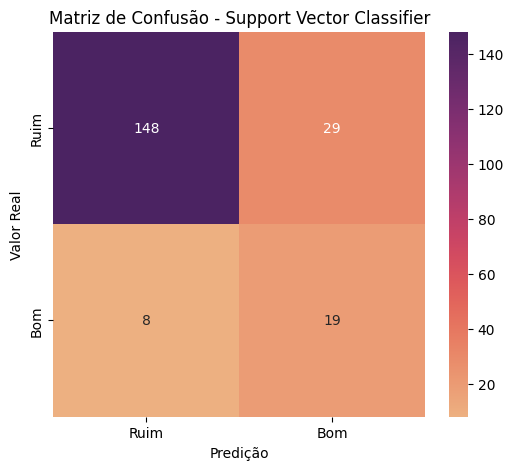

Total pela matriz: 204
Acertos pela matriz: 167


In [147]:
# Matriz de confusão 

from sklearn.metrics import confusion_matrix
matriz = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(6,5))
sns.heatmap(matriz,annot=True,fmt="d",cmap="flare",xticklabels=["Ruim", "Bom"],yticklabels=["Ruim", "Bom"])
plt.title("Matriz de Confusão - Support Vector Classifier")
plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.show()

cm_svc = confusion_matrix(y_test, y_pred_svc)

print("Total pela matriz:", cm_svc.sum())
print("Acertos pela matriz:", cm_svc.diagonal().sum())

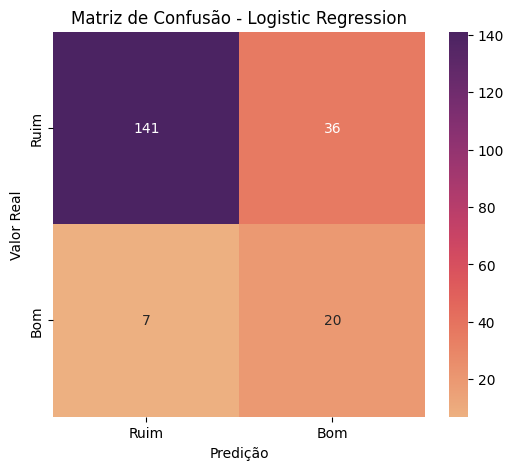

Total pela matriz: 204
Acertos pela matriz: 161


In [148]:
# Matriz de confusão 

from sklearn.metrics import confusion_matrix
matriz = confusion_matrix(y_test, y_pred_regre)
plt.figure(figsize=(6,5))
sns.heatmap(matriz,annot=True,fmt="d",cmap="flare",xticklabels=["Ruim", "Bom"],yticklabels=["Ruim", "Bom"])
plt.title("Matriz de Confusão - Logistic Regression")
plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.show()

cm_regre = confusion_matrix(y_test, y_pred_regre)

print("Total pela matriz:", cm_regre.sum())
print("Acertos pela matriz:", cm_regre.diagonal().sum())

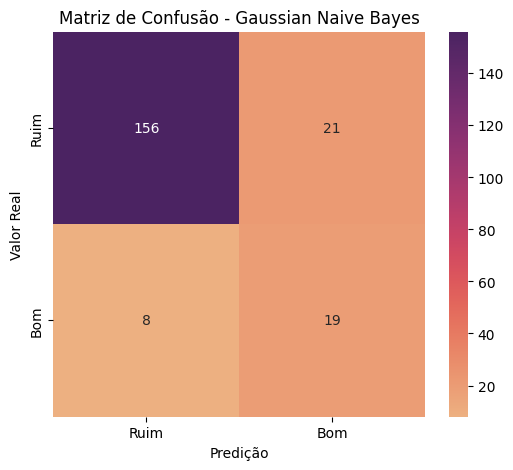

Total pela matriz: 204
Acertos pela matriz: 175


In [149]:
# Matriz de confusão 

from sklearn.metrics import confusion_matrix
matriz = confusion_matrix(y_test, y_pred_gnb)
plt.figure(figsize=(6,5))
sns.heatmap(matriz,annot=True,fmt="d",cmap="flare",xticklabels=["Ruim", "Bom"],yticklabels=["Ruim", "Bom"])
plt.title("Matriz de Confusão - Gaussian Naive Bayes")
plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.show()

cm_gnb = confusion_matrix(y_test, y_pred_gnb)

print("Total pela matriz:", cm_gnb.sum())
print("Acertos pela matriz:", cm_gnb.diagonal().sum())

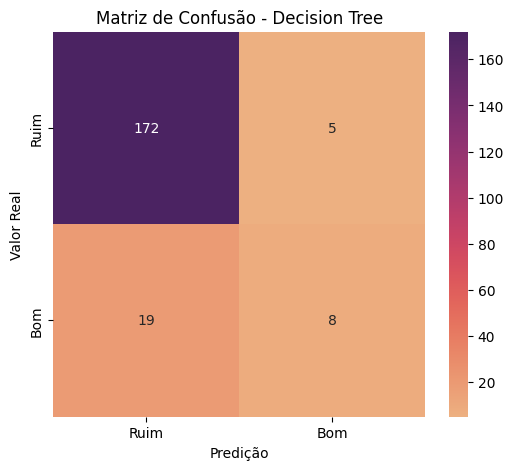

Total pela matriz: 204
Acertos pela matriz: 180


In [150]:
# Matriz de confusão 

from sklearn.metrics import confusion_matrix
matriz = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6,5))
sns.heatmap(matriz,annot=True,fmt="d",cmap="flare",xticklabels=["Ruim", "Bom"],yticklabels=["Ruim", "Bom"])
plt.title("Matriz de Confusão - Decision Tree")
plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.show()

cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Total pela matriz:", cm_tree.sum())
print("Acertos pela matriz:", cm_tree.diagonal().sum())

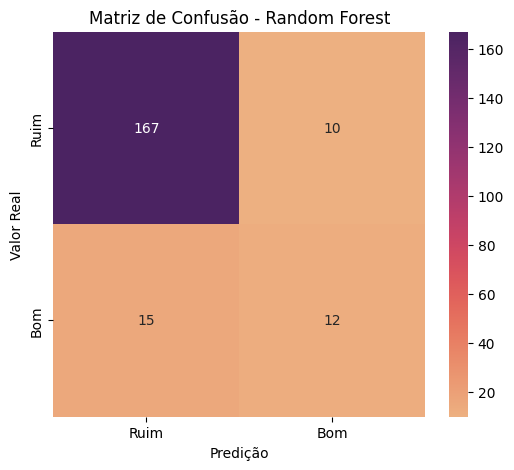

Total pela matriz: 204
Acertos pela matriz: 179


In [151]:
# Matriz de confusão 

from sklearn.metrics import confusion_matrix
matriz = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(matriz,annot=True,fmt="d",cmap="flare",xticklabels=["Ruim", "Bom"],yticklabels=["Ruim", "Bom"])
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.show()

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Total pela matriz:", cm_rf.sum())
print("Acertos pela matriz:", cm_rf.diagonal().sum())

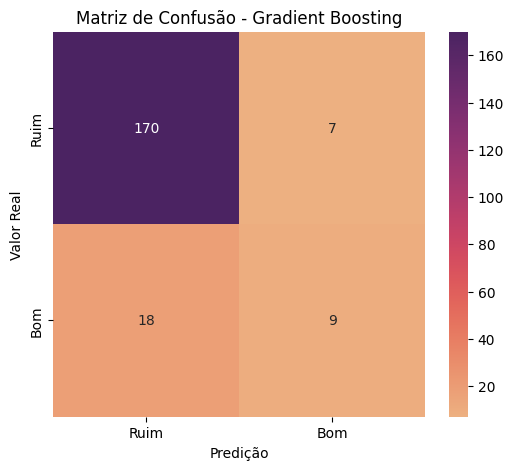

Total pela matriz: 204
Acertos pela matriz: 179


In [152]:
# Matriz de confusão 

from sklearn.metrics import confusion_matrix
matriz = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6,5))
sns.heatmap(matriz,annot=True,fmt="d",cmap="flare",xticklabels=["Ruim", "Bom"],yticklabels=["Ruim", "Bom"])
plt.title("Matriz de Confusão - Gradient Boosting")
plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.show()

cm_gb = confusion_matrix(y_test, y_pred_gb)

print("Total pela matriz:", cm_gb.sum())
print("Acertos pela matriz:", cm_gb.diagonal().sum())

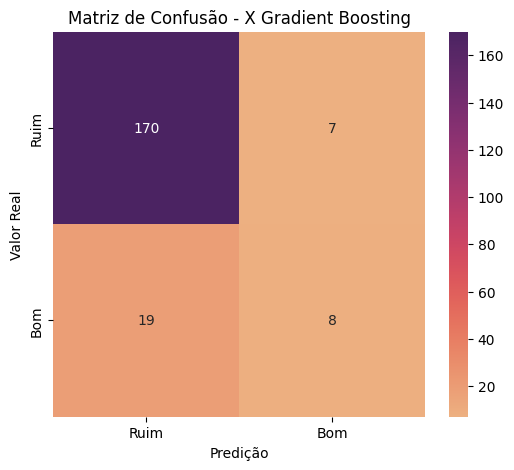

Total pela matriz: 204
Acertos pela matriz: 178


In [153]:
# Matriz de confusão 

from sklearn.metrics import confusion_matrix
matriz = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(matriz,annot=True,fmt="d",cmap="flare",xticklabels=["Ruim", "Bom"],yticklabels=["Ruim", "Bom"])
plt.title("Matriz de Confusão - X Gradient Boosting")
plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.show()

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("Total pela matriz:", cm_xgb.sum())
print("Acertos pela matriz:", cm_xgb.diagonal().sum())

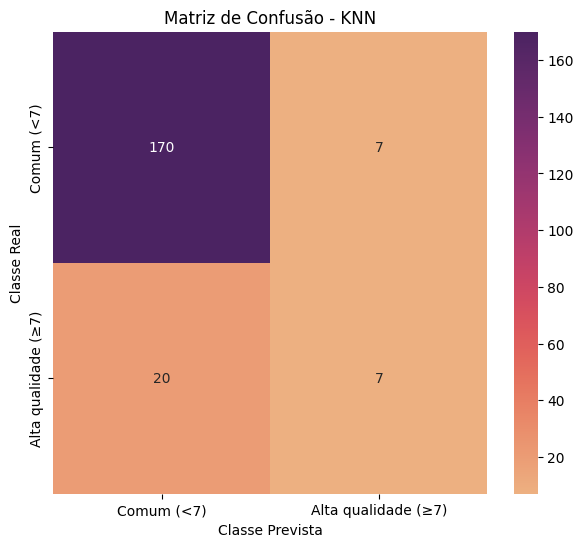

Total pela matriz: 204
Acertos pela matriz: 177


In [154]:
# Matriz de confusão
cm_knn = confusion_matrix(y_test, y_pred_KNN)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="flare",
    xticklabels=["Comum (<7)", "Alta qualidade (≥7)"],
    yticklabels=["Comum (<7)", "Alta qualidade (≥7)"]
)

plt.title("Matriz de Confusão - KNN")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.show()

print("Total pela matriz:", cm_knn.sum())
print("Acertos pela matriz:", cm_knn.diagonal().sum())